# GAN — Synthetic Data Generation (minimal real run)

Train a tiny GAN on 2D Gaussian mixture (offline) and plot generated samples.

_Last rebuild: **2026-02-16 07:18:50**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.figsize']=(6,6)


In [2]:
# Real data: 2D mixture
N=4000
centers = np.array([[0,0],[3,0],[0,3],[-3,0],[0,-3]], dtype='float32')
idx = np.random.randint(0, len(centers), size=N)
real = centers[idx] + np.random.normal(0, 0.3, size=(N,2)).astype('float32')
real_t = torch.tensor(real)


In [3]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

G = nn.Sequential(nn.Linear(8, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 2)).to(device)
D = nn.Sequential(nn.Linear(2, 32), nn.ReLU(), nn.Linear(32, 32), nn.ReLU(), nn.Linear(32, 1)).to(device)

optG = torch.optim.Adam(G.parameters(), lr=2e-4)
optD = torch.optim.Adam(D.parameters(), lr=2e-4)
loss_fn = nn.BCEWithLogitsLoss()

def batch(bs=256):
    ix = torch.randint(0, real_t.shape[0], (bs,))
    return real_t[ix].to(device)

for step in range(800):
    x_real = batch()
    z = torch.randn(x_real.size(0), 8, device=device)
    x_fake = G(z).detach()

    # D
    optD.zero_grad()
    lossD = loss_fn(D(x_real), torch.ones(x_real.size(0),1,device=device)) +             loss_fn(D(x_fake), torch.zeros(x_fake.size(0),1,device=device))
    lossD.backward(); optD.step()

    # G
    z = torch.randn(x_real.size(0), 8, device=device)
    optG.zero_grad()
    gen = G(z)
    lossG = loss_fn(D(gen), torch.ones(gen.size(0),1,device=device))
    lossG.backward(); optG.step()

    if (step+1) % 200 == 0:
        print('step', step+1, 'lossD', float(lossD), 'lossG', float(lossG))


step 200 lossD 1.0456217527389526 lossG 0.7137618660926819
step 400 lossD 1.362414836883545 lossG 0.5026088953018188
step 600 lossD 1.394761085510254 lossG 0.8747201561927795
step 800 lossD 1.2733891010284424 lossG 1.1418251991271973


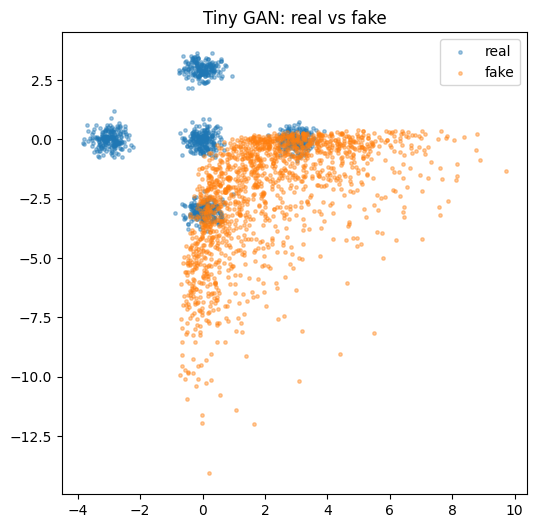

In [4]:
# Plot samples
with torch.no_grad():
    z = torch.randn(1500, 8, device=device)
    fake = G(z).cpu().numpy()

plt.scatter(real[:1000,0], real[:1000,1], s=6, alpha=0.4, label='real')
plt.scatter(fake[:,0], fake[:,1], s=6, alpha=0.4, label='fake')
plt.legend(); plt.title('Tiny GAN: real vs fake'); plt.show()

In [5]:
print('DONE 2026-02-16 07:18:50')

DONE 2026-02-16 07:18:50
